<a href="https://colab.research.google.com/github/michgdigital1/sorteoamigos/blob/main/CHALLENGE_2ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_json("/content/TelecomX_Data.json")


In [3]:
df.head()


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [4]:
df.info()
df.describe(include="all")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


,customerID,Churn,customer,phone,internet,account
count,7267,7267,7267,7267,7267,7267
unique,7267,3,891,3,129,6931
top,9995-HOTOH,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
freq,1,5174,223,3495,1581,6


In [5]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df.isnull().sum()
df = df.dropna()


In [6]:
churn_rate = df["Churn"].mean() * 100
churn_rate


np.float64(26.536987079369588)

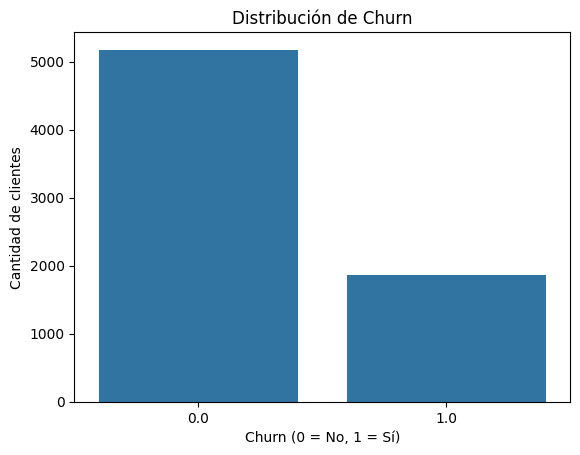

In [7]:
sns.countplot(x="Churn", data=df)
plt.title("Distribución de Churn")
plt.xlabel("Churn (0 = No, 1 = Sí)")
plt.ylabel("Cantidad de clientes")
plt.show()


In [10]:
df.columns


Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [11]:
df["Contract"] = df["account"].apply(lambda x: x["Contract"])


In [12]:
df["Contract"].value_counts()


,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


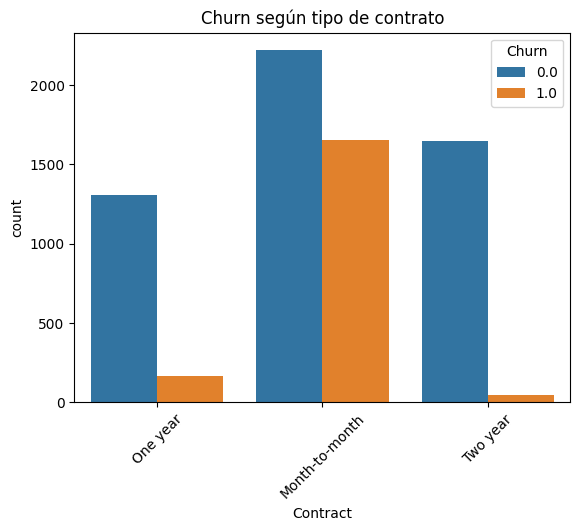

In [13]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn según tipo de contrato")
plt.xticks(rotation=45)
plt.show()


In [16]:
df["account"].iloc[0]


{'Contract': 'One year',
 'PaperlessBilling': 'Yes',
 'PaymentMethod': 'Mailed check',
 'Charges': {'Monthly': 65.6, 'Total': '593.3'}}

In [17]:
df["MonthlyCharges"] = df["account"].apply(lambda x: x["Charges"]["Monthly"])


In [18]:
df["MonthlyCharges"].head()


,MonthlyCharges
0,65.6
1,59.9
2,73.9
3,98.0
4,83.9


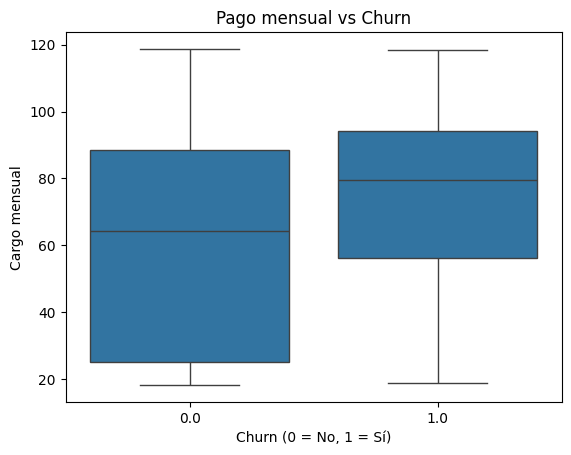

In [19]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Pago mensual vs Churn")
plt.xlabel("Churn (0 = No, 1 = Sí)")
plt.ylabel("Cargo mensual")
plt.show()


In [20]:
df.groupby("Churn")["MonthlyCharges"].mean()


,MonthlyCharges
Churn,
0.0,61.265124
1.0,74.441332
